# LSTM 기반 품목별 수요예측
B 물류센터 봉지라면·탄산음료의 2025년 1~3월 매입·매출 수량 예측

### LSTM을 선택한 이유

- 월별 수요 데이터는 계절성, 트렌드, 외부 이벤트(명절·폭염 등)가 복합적으로 얽힌 비선형 시계열이다. 

- ARIMA, SARIMAX 같은 전통적 통계 모형은 선형 관계를 가정하므로 이러한 복합 패턴을 충분히 반영하기 어렵다.

- LSTM은 Short-term memory를 중심으로 최근 과거의 패턴을 더 강하게 학습하는 구조로, 수요 예측처럼 가장 최근 데이터가 다음 달 수요에 더 큰 영향을 미치는 도메인에 적합하다. 

- 또한 이상치가 포함된 데이터에서도 전체 패턴을 안정적으로 학습하는 특성 덕분에 전처리 한계를 어느 정도 보완할 수 있었다.

| 모델 | 입력 변수 |
|------|----------|
| Model 1 | EA 단일 |
| Model 2 | EA + 결측 보정 |
| Model 3 | EA + 외생변수 |

→ 세 모델 성능 비교



## 1. 환경 세팅

In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
import seaborn as sns

import tensorflow as tf #딥러닝 프레임워크
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 2. 난수값 고정

딥러닝은 난수 기반 학습이기 때문에 실행할 때마다 결과가 달라질 수 있음. 

이를 방지하기 위해 모든 난수 생성기를 고정.


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import subprocess
    subprocess.run(['apt-get','install','-y','fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    nanum = [f for f in fm.findSystemFonts() if 'Nanum' in f]
    if nanum:
        plt.rcParams['font.family'] = fm.FontProperties(fname=nanum[0]).get_name()
plt.rcParams['axes.unicode_minus'] = False



## 3. 데이터 로드

In [4]:
save_path = "/Users/danha/Desktop/IT/project/공모전/raw/data/"

df_final = pd.read_csv(save_path + "Model C - EA + 외생변수.csv", encoding='utf-8-sig')
df_final['연월'] = pd.to_datetime(df_final['연월'])
df_final = df_final.sort_values(['품목','연월']).reset_index(drop=True)

print(f"기간: {df_final['연월'].min().strftime('%Y-%m')} ~ {df_final['연월'].max().strftime('%Y-%m')}")
display(df_final.head(6))


기간: 2021-01 ~ 2024-12


,연월,매입수량,매출수량,품목
0,2021-01-01,24209,3476,봉지라면
1,2021-02-01,19935,2214,봉지라면
2,2021-03-01,29570,3650,봉지라면
3,2021-04-01,26777,2631,봉지라면
4,2021-05-01,18407,3026,봉지라면
5,2021-06-01,16678,2411,봉지라면


## 4. LSTM 공통 함수 정의

In [5]:
# 시퀀스 생성 
def make_sequences(data: np.ndarray, window: int):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)


# LSTM 모델 빌더
def build_lstm(input_shape, output_dim, units=(64, 32), dropout=0.2):
    """2-Layer LSTM + BatchNorm + Dropout + Dense (기술서 구조 반영)"""
    inp = Input(shape=input_shape)
    x = LSTM(units[0], return_sequences=True)(inp)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = LSTM(units[1], return_sequences=False)(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = Dense(output_dim)(x)
    x = BatchNormalization()(x)
    model = Model(inp, x)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
    return model


# 평가 지표 
def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    if label:
        print(f'  [{label}]  RMSE={rmse:.4f}  MAE={mae:.4f}')
    return rmse, mae


# 테스트 구간 예측 시각화 함수
def plot_pred(dates, y_true, y_pred, col_idx, col_name, 품목, model_name, ax, color):
    ax.plot(dates, y_true[:, col_idx], color='gray', linewidth=1.5,
            label='실제값', linestyle='--', alpha=0.8)
    ax.plot(dates, y_pred[:, col_idx], color=color, linewidth=2,
            label=f'{model_name} 예측', marker='s', markersize=4)
    ax.set_title(f'{품목}  {col_name}  —  {model_name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('수량 (EA)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)


WINDOW = 6    # 과거 6개월 → 다음 1개월 예측
EPOCHS = 200
BATCH  = 8
PRED_N = 3    # 2025년 1~3월 (3개월 롤링 예측)

callbacks = [
    EarlyStopping(patience=30, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=15, factor=0.5, min_lr=1e-5),
]


## 5. Model A, B, C 학습 및 평가

각 모델을 품목별(봉지라면·탄산음료)로 학습하고, 검증 성능(RMSE/MAE)을 비교한다.

- **train**: 2021-01 ~ 2023-12 (36개월)
- **test** : 2024-01 ~ 2024-12 (12개월)
- **예측** : 2025-01 ~ 2025-03 (3개월)

품목 특성에 따라 최적 모델 구조가 달라졌으며, 특히 탄산음료는 매입과 매출 예측에 서로 다른 모델이 최적임을 확인하였다. 이는 수요 변동성 차이에 따라것으로 해석된다.

RMSE/MAE은 값이 낮을수록 성능이 좋음.

In [6]:
EXOG_COLS = [c for c in ['평균기온','평균일교차','강수량',
                          '폭염일수','한파일수','CPI_라면','CPI_탄산',
                          'COVID_19','명절']
             if c in df_final.columns]

TARGET_COLS = ['매입수량', '매출수량']
all_results = {}
all_scalers = {}
품목_colors  = {'봉지라면': '#e74c3c', '탄산음료': '#3498db'}

N_TEST = 12   # 2024년 12개월 → 테스트
N_VAL  = 6    # 마지막 6개월을 validation으로 명시적 분리

for 품목 in ['봉지라면', '탄산음료']:
    print(f'  ▶ {품목}')

    sub  = df_final[df_final['품목'] == 품목].sort_values('연월').reset_index(drop=True)
    연월  = sub['연월'].values

    # Model 별 피처 정의
    # Model 2: lag 피처 추가
    lag_cols = []
    for col in TARGET_COLS:
        sub[f'{col}_lag1'] = sub[col].shift(1).fillna(method='bfill')
        sub[f'{col}_lag3'] = sub[col].shift(3).fillna(method='bfill')
        lag_cols += [f'{col}_lag1', f'{col}_lag3']

    feat_m1 = TARGET_COLS                           # EA 단일
    feat_m2 = TARGET_COLS + lag_cols                # EA + lag 피처
    feat_m3 = TARGET_COLS + EXOG_COLS               # EA + 외생변수

    for model_name, feat_cols in [('Model1', feat_m1),
                                   ('Model2', feat_m2),
                                   ('Model3', feat_m3)]:

        data_raw = sub[feat_cols].values.astype(float)

        # Train / Val / Test 분리 
        n_total = len(data_raw)
        n_test  = N_TEST
        n_val   = N_VAL
        n_train = n_total - n_test - n_val

        train_raw = data_raw[:n_train]
        val_raw   = data_raw[n_train : n_train + n_val]
        test_raw  = data_raw[n_train + n_val :]      

        # train에 scaler fit
        scaler = MinMaxScaler()
        scaler.fit(train_raw)

        train_sc = scaler.transform(train_raw)
        val_sc   = scaler.transform(val_raw)
        test_sc  = scaler.transform(test_raw)

        if model_name == 'Model3':
            all_scalers[품목] = scaler

        train_full = train_sc
        val_full   = np.vstack([train_sc[-WINDOW:], val_sc])
        test_full  = np.vstack([val_sc[-WINDOW:],   test_sc])

        X_tr, y_tr = make_sequences(train_full, WINDOW)
        X_va, y_va = make_sequences(val_full,   WINDOW)
        X_te, y_te = make_sequences(test_full,  WINDOW)
        연월_test   = 연월[n_train + n_val:]

        # 모델 학습
        model = build_lstm(
            input_shape=(WINDOW, len(feat_cols)),
            output_dim=len(feat_cols),
        )
        model.fit(X_tr, y_tr,
                  validation_data=(X_va, y_va),  
                  epochs=EPOCHS, batch_size=BATCH,
                  callbacks=callbacks, verbose=0)

        # 테스트 예측
        pred_sc  = model.predict(X_te, verbose=0)
        pred_inv = scaler.inverse_transform(pred_sc)
        true_inv = scaler.inverse_transform(y_te)

        rmse_매입, mae_매입 = evaluate(true_inv[:,0], pred_inv[:,0], f'{model_name} 매입')
        rmse_매출, mae_매출 = evaluate(true_inv[:,1], pred_inv[:,1], f'{model_name} 매출')

        # 025년 1~3월 예측
        last_seq     = np.vstack([val_sc, test_sc])[-WINDOW:].copy()
        future_preds = []
        for _ in range(PRED_N):
            x_in   = last_seq.reshape(1, WINDOW, len(feat_cols))
            y_next = model.predict(x_in, verbose=0)[0]
            future_preds.append(y_next)
            last_seq = np.vstack([last_seq[1:], y_next])
        future_inv = scaler.inverse_transform(np.array(future_preds))

        all_results[(품목, model_name)] = {
            'rmse_매입': rmse_매입, 'mae_매입': mae_매입,
            'rmse_매출': rmse_매출, 'mae_매출': mae_매출,
            'pred_inv':   pred_inv,
            'true_inv':   true_inv,
            'future_inv': future_inv,
            '연월_test':  연월_test,
        }


  ▶ 봉지라면
  [Model1 매입]  RMSE=2371.2402  MAE=2001.1335
  [Model1 매출]  RMSE=368.0199  MAE=315.7369
  [Model2 매입]  RMSE=3815.7335  MAE=3349.3232
  [Model2 매출]  RMSE=409.9973  MAE=362.2340
  [Model3 매입]  RMSE=6260.7101  MAE=5773.0924
  [Model3 매출]  RMSE=370.6283  MAE=316.4782
  ▶ 탄산음료
  [Model1 매입]  RMSE=6416.6163  MAE=5165.6037
  [Model1 매출]  RMSE=3506.7217  MAE=2745.2784
  [Model2 매입]  RMSE=6586.7034  MAE=5151.1528
  [Model2 매출]  RMSE=3324.2899  MAE=2643.6003
  [Model3 매입]  RMSE=6388.0329  MAE=5143.5528
  [Model3 매출]  RMSE=4060.8175  MAE=3393.3110


## 6. 모델별 성능 비교

성능 비교 결과, 품목 및 지표에 따라 최적 모델이 상이하게 나타났다.

봉지라면은 Model1이 우수했으며, 탄산음료 매출은 Model2가 가장 낮은 오차를 보였다.

다만 외생변수를 포함한 Model3는 전반적으로 안정적인 성능을 보여 최종 예측 모델로 채택하였다.

,품목,모델,매입 RMSE,매입 MAE,매출 RMSE,매출 MAE
0,봉지라면,Model1,2371.2402,2001.1335,368.0199,315.7369
1,봉지라면,Model2,3815.7335,3349.3232,409.9973,362.2340
2,봉지라면,Model3,6260.7101,5773.0924,370.6283,316.4782
3,탄산음료,Model1,6416.6163,5165.6037,3506.7217,2745.2784
4,탄산음료,Model2,6586.7034,5151.1528,3324.2899,2643.6003
5,탄산음료,Model3,6388.0329,5143.5528,4060.8175,3393.3110


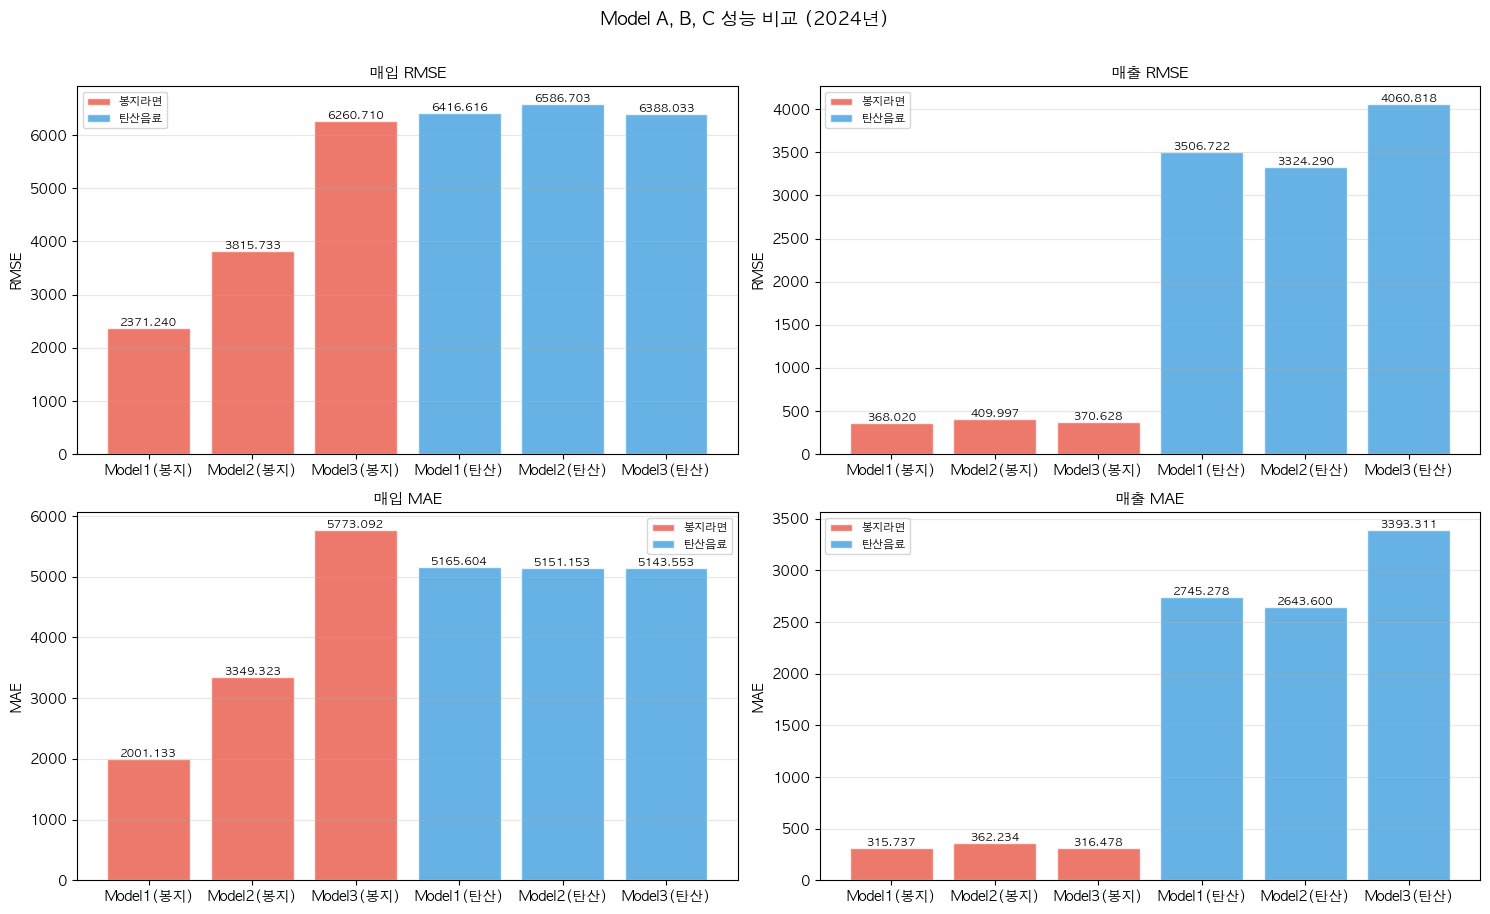

In [7]:
# RMSE / MAE
rows = []
for (품목, model_name), res in all_results.items():
    rows.append({
        '품목': 품목, '모델': model_name,
        '매입 RMSE': round(res['rmse_매입'], 4),
        '매입 MAE':  round(res['mae_매입'],  4),
        '매출 RMSE': round(res['rmse_매출'], 4),
        '매출 MAE':  round(res['mae_매출'],  4),
    })

perf_df = pd.DataFrame(rows)
display(perf_df)

#성능 비교 바 차트
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
metrics = [('매입 RMSE','매입'), ('매출 RMSE','매출'),
           ('매입 MAE', '매입'), ('매출 MAE', '매출')]

for ax, (metric, 타겟) in zip(axes.flat, metrics):
    for 품목, color in 품목_colors.items():
        sub_p = perf_df[perf_df['품목'] == 품목]
        bars = ax.bar(
            [f'{m}({품목[:2]})' for m in sub_p['모델']],
            sub_p[metric],
            color=color, alpha=0.75, edgecolor='white', label=품목
        )
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{metric}', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric.split()[-1])
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model A, B, C 성능 비교 (2024년)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



## 7. 2025년 1~3월 예측 결과 (Model 3)

Model 3(외생변수 포함)을 기반으로 2025년 1~3월 수요를 예측한 결과, 

봉지라면은 매입·매출 모두 증가 추세를 보였으며, 탄산음료는 매입은 증가하나 매출은 소폭 감소하는 것으로 나타났다.

아마도 겨울철 라면 수요 증가, 탄산음료 비수기, 기온 변수 영향 등으로 봉지라면은 증가하고 탄산은 감소한 것으로 예상된다.

따라서, 봉지라면은 3월 최대 수요를 대비해 발주 수량을 늘리고, 탄산음료는 재고 관리 전략이 필요하다.


In [8]:
# 2025년 1~3월 예측값 정리
future_months = pd.date_range('2025-01', periods=3, freq='MS')
future_rows = []

for 품목 in ['봉지라면', '탄산음료']:
    res = all_results[(품목, 'Model3')]
    for i, month in enumerate(future_months):
        future_rows.append({
            '품목': 품목,
            '연월': month.strftime('%Y-%m'),
            '예측_매입수량(EA)': round(res['future_inv'][i, 0]),
            '예측_매출수량(EA)': round(res['future_inv'][i, 1]),
        })


future_df = pd.DataFrame(future_rows)
display(future_df)


,품목,연월,예측_매입수량(EA),예측_매출수량(EA)
0,봉지라면,2025-01,12979,2455
1,봉지라면,2025-02,13395,2477
2,봉지라면,2025-03,13899,2501
3,탄산음료,2025-01,13484,12414
4,탄산음료,2025-02,13782,12379
5,탄산음료,2025-03,13929,12302


## 8. 회고

- 공모전 기간에는 역할을 분담해 데이터 전처리와 보고서 작성만 진행했지만, 이후 혼자 상관분석, t-test, 의사결정나무, 그리고 LSTM 모델링까지 수행하여 2025년 1~3월 수요 예측을 직접 진행했다.

- 일별 데이터를 월별로 집계하고, 품목별로 데이터 구조를 만들어 결측치 및 이상치를 처리하고, 외생 변수 결합을 직접 해보면서 모델링을 하기위해 깨끗하게 정리된 데이터 구조가 정말 중요하단 것을 알았다. CPI와 기상 데이터는 단순 병합이 아닌, 시계열 기준을 맞춰야 한다는 점에서 많은 시행착오를 겪었다.

- 변수 선택을 하면서 연속형 변수와 이진형 변수의 특성에 맞는 방법을 적용해야 한다는 점것을 알게되었고, 왜 이 모델을 사용하는가? 에 대해 고민하며 그 과정에서 각각의 모델 구조를 자세히 이해 할 수 있었다.

